In [1]:
!pip install deepxde

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 195.4/195.4 kB 10.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.8/107.8 kB 13.0 MB/s eta 0:00:00


# **1. Problemas Diretos**

## **1.1 Equação de Calor**

Descreve a evolução da temperatura ao longo de uma barra devido à difusão térmica. O calor se propaga no espaço ao longo do tempo, considerando uma difusividade térmica constante, uma distribuição inicial senoidal e temperatura nula nas extremidades.

### Configuração do problema

Vamos resolver uma equação do calor:

$$ \frac{\partial u}{\partial t} = \alpha \frac{\partial^2 u}{\partial x^2}, \quad x \in [0, 1], \quad t \in [0, 1] $$

onde $\alpha = 0.4$ é a constante de difusividade térmica.

Com condições de contorno de Dirichlet:

$$ u(0, t) = u(1, t) = 0, $$

e condição inicial periódica (senoidal):

$$ u(x, 0) = \sin\left(\frac{n\pi x}{L}\right), \quad 0 < x < L, \quad n = 1, 2, \dots $$

onde $L = 1$ é o comprimento da barra, $n = 1$ é a frequência das condições iniciais senoidais.

A solução exata é
$$u(x, t) = \exp \left(\frac{-n^2\pi^2\alpha t}{L^2} \right) \sin\left(\frac{n\pi x}{L}\right)$$.

No backend selected.
Finding available backend...
Found tensorflow
Using backend: tensorflow
Other supported backends: tensorflow.compat.v1, pytorch, jax, paddle.
paddle supports more examples now and is recommended.


Setting the default backend to "tensorflow". You can change it in the ~/.deepxde/config.json file or export the DDE_BACKEND environment variable. Valid options are: tensorflow.compat.v1, tensorflow, pytorch, jax, paddle (all lowercase)


Enable just-in-time compilation with XLA.

/tmp/ipykernel_4361/1959669053.py:34: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  usol[i][j] = heat_eq_exact_solution(x[i], t[j])


Compiling model...
'compile' took 0.308968 s

Training model...



Cause: could not parse the source code of <function <lambda> at 0x786509b79d00>: no matching AST found among candidates:
# coding=utf-8
lambda x, on: np.array([on_boundary(x[i], on[i]) for i in range(len(x))])
# coding=utf-8
lambda x, on: np.array([on_boundary1(x[i], on[i]) for i in range(len(x))])
# coding=utf-8
lambda x, on: np.array([on_boundary2(x[i], on[i]) for i in range(len(x))])
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert


Cause: could not parse the source code of <function <lambda> at 0x786509b79d00>: no matching AST found among candidates:
# coding=utf-8
lambda x, on: np.array([on_boundary(x[i], on[i]) for i in range(len(x))])
# coding=utf-8
lambda x, on: np.array([on_boundary1(x[i], on[i]) for i in range(len(x))])
# coding=utf-8
lambda x, on: np.array([on_boundary2(x[i], on[i]) for i in range(len(x))])
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert


Cause: could not parse the source code of <function <lambda> at 0x786509b7a020>: no matching AST found among candidates:
# coding=utf-8
lambda x, on: np.array([on_boundary(x[i], on[i]) for i in range(len(x))])
# coding=utf-8
lambda x, on: np.array([on_boundary1(x[i], on[i]) for i in range(len(x))])
# coding=utf-8
lambda x, on: np.array([on_boundary2(x[i], on[i]) for i in range(len(x))])
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert


Cause: could not parse the source code of <function <lambda> at 0x786509b7a020>: no matching AST found among candidates:
# coding=utf-8
lambda x, on: np.array([on_boundary(x[i], on[i]) for i in range(len(x))])
# coding=utf-8
lambda x, on: np.array([on_boundary1(x[i], on[i]) for i in range(len(x))])
# coding=utf-8
lambda x, on: np.array([on_boundary2(x[i], on[i]) for i in range(len(x))])
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Step      Train loss                        Test loss                         Test metric
0         [9.86e-01, 2.21e-01, 6.79e-01]    [9.76e-01, 2.21e-01, 6.79e-01]    []  
1000      [6.06e-03, 5.55e-03, 8.58e-03]    [3.20e-03, 5.55e-03, 8.58e-03]    []  
2000      [7.10e-04, 1.34e-04, 1.88e-04]    [4.60e-04, 1.34e-04, 1.88e-04]    []  
3000      [1.92e-04, 5.08e-05, 4.27e-05]    [1.38e-04, 5.08e-05, 4.27e-05]    []  
4000      [1.11e-04, 2.75e-05, 1.59e-05]    [7.62e-05, 2.75e-05, 1.59e-05]    []  
5000      [

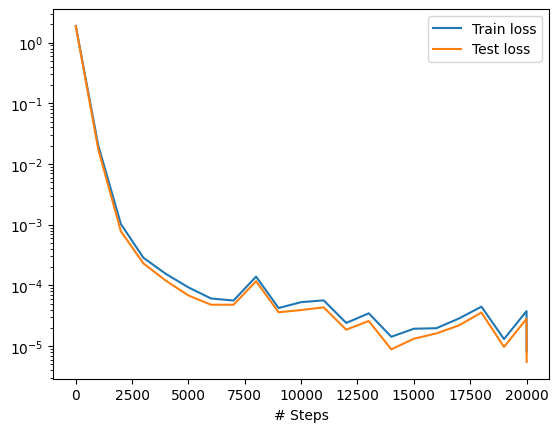

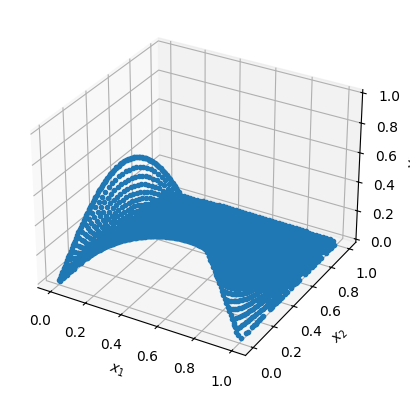

Mean residual: 0.00171428
L2 relative error: 0.0016191713342745245


In [2]:
"""Backend supported: tensorflow.compat.v1, tensorflow, pytorch, paddle"""
import deepxde as dde
import numpy as np


def heat_eq_exact_solution(x, t):
    """Returns the exact solution for a given x and t (for sinusoidal initial conditions).

    Parameters
    ----------
    x : np.ndarray
    t : np.ndarray
    """
    return np.exp(-(n**2 * np.pi**2 * a * t) / (L**2)) * np.sin(n * np.pi * x / L)


def gen_exact_solution():
    """Generates exact solution for the heat equation for the given values of x and t."""
    # Number of points in each dimension:
    x_dim, t_dim = (256, 201)

    # Bounds of 'x' and 't':
    x_min, t_min = (0, 0.0)
    x_max, t_max = (L, 1.0)

    # Create tensors:
    t = np.linspace(t_min, t_max, num=t_dim).reshape(t_dim, 1)
    x = np.linspace(x_min, x_max, num=x_dim).reshape(x_dim, 1)
    usol = np.zeros((x_dim, t_dim)).reshape(x_dim, t_dim)

    # Obtain the value of the exact solution for each generated point:
    for i in range(x_dim):
        for j in range(t_dim):
            usol[i][j] = heat_eq_exact_solution(x[i], t[j])

    # Save solution:
    np.savez("heat_eq_data", x=x, t=t, usol=usol)


def gen_testdata():
    """Import and preprocess the dataset with the exact solution."""
    # Load the data:
    data = np.load("heat_eq_data.npz")
    # Obtain the values for t, x, and the excat solution:
    t, x, exact = data["t"], data["x"], data["usol"].T
    # Process the data and flatten it out (like labels and features):
    xx, tt = np.meshgrid(x, t)
    X = np.vstack((np.ravel(xx), np.ravel(tt))).T
    y = exact.flatten()[:, None]
    return X, y


# Problem parameters:
a = 0.4  # Thermal diffusivity
L = 1  # Length of the bar
n = 1  # Frequency of the sinusoidal initial conditions

# Generate a dataset with the exact solution (if you dont have one):
gen_exact_solution()


def pde(x, y):
    """Expresses the PDE residual of the heat equation."""
    dy_t = dde.grad.jacobian(y, x, i=0, j=1)
    dy_xx = dde.grad.hessian(y, x, i=0, j=0)
    return dy_t - a * dy_xx


# Computational geometry:
geom = dde.geometry.Interval(0, L)
timedomain = dde.geometry.TimeDomain(0, 1)
geomtime = dde.geometry.GeometryXTime(geom, timedomain)

# Initial and boundary conditions:
bc = dde.icbc.DirichletBC(geomtime, lambda x: 0, lambda _, on_boundary: on_boundary)
ic = dde.icbc.IC(
    geomtime,
    lambda x: np.sin(n * np.pi * x[:, 0:1] / L),
    lambda _, on_initial: on_initial,
)

# Define the PDE problem and configurations of the network:
data = dde.data.TimePDE(
    geomtime,
    pde,
    [bc, ic],
    num_domain=2540,
    num_boundary=80,
    num_initial=160,
    num_test=2540,
)
net = dde.nn.FNN([2] + [20] * 3 + [1], "tanh", "Glorot normal")
model = dde.Model(data, net)

# Build and train the model:
model.compile("adam", lr=1e-3)
model.train(iterations=20000)
model.compile("L-BFGS")
losshistory, train_state = model.train()

# Plot/print the results
dde.saveplot(losshistory, train_state, issave=True, isplot=True)
X, y_true = gen_testdata()
y_pred = model.predict(X)
f = model.predict(X, operator=pde)
print("Mean residual:", np.mean(np.absolute(f)))
print("L2 relative error:", dde.metrics.l2_relative_error(y_true, y_pred))
np.savetxt("test.dat", np.hstack((X, y_true, y_pred)))

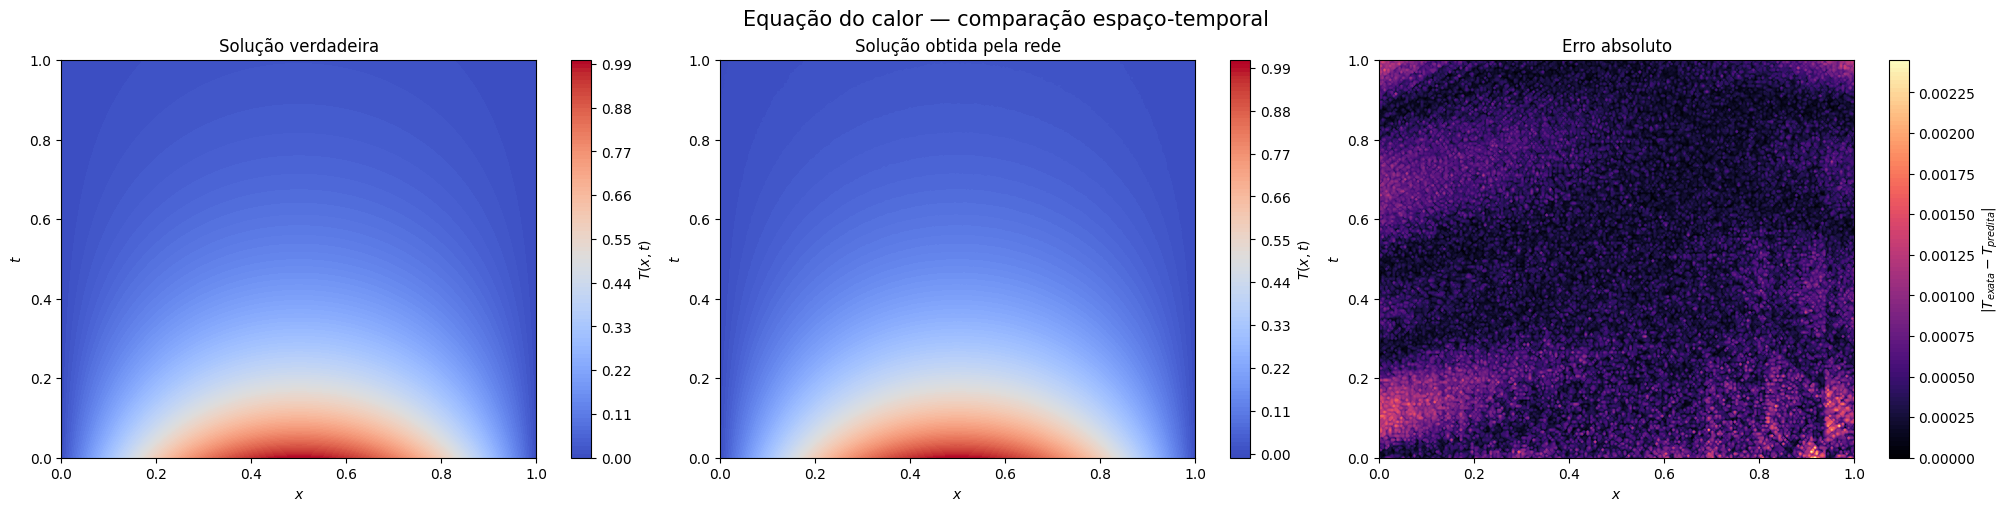

Erro absoluto máximo: 2.449987e-03
Erro absoluto médio: 3.173875e-04


In [3]:
import matplotlib.pyplot as plt

x_plot = np.unique(X[:, 0])
t_plot = np.unique(X[:, 1])

T_true = y_true.reshape(len(t_plot), len(x_plot))
T_pred = y_pred.reshape(len(t_plot), len(x_plot))
absolute_error = np.abs(T_true - T_pred)

vmin = min(T_true.min(), T_pred.min())
vmax = max(T_true.max(), T_pred.max())
error_max = absolute_error.max()

fig, axes = plt.subplots(1, 3, figsize=(20, 5), constrained_layout=True)

contour_true = axes[0].contourf(
    x_plot,
    t_plot,
    T_true,
    levels=100,
    cmap="coolwarm",
    vmin=vmin,
    vmax=vmax,
)

contour_pred = axes[1].contourf(
    x_plot,
    t_plot,
    T_pred,
    levels=100,
    cmap="coolwarm",
    vmin=vmin,
    vmax=vmax,
)

contour_error = axes[2].contourf(
    x_plot,
    t_plot,
    absolute_error,
    levels=100,
    cmap="magma",
    vmin=0,
    vmax=error_max,
)

axes[0].set_title("Solução verdadeira")
axes[1].set_title("Solução obtida pela rede")
axes[2].set_title("Erro absoluto")

for ax in axes:
    ax.set_xlabel("$x$")
    ax.set_ylabel("$t$")
    ax.set_aspect("auto")

fig.colorbar(contour_true, ax=axes[0], label="$T(x,t)$")
fig.colorbar(contour_pred, ax=axes[1], label="$T(x,t)$")
fig.colorbar(contour_error, ax=axes[2], label="$|T_{exata}-T_{predita}|$")

fig.suptitle("Equação do calor — comparação espaço-temporal", fontsize=15)

plt.show()

print(f"Erro absoluto máximo: {absolute_error.max():.6e}")
print(f"Erro absoluto médio: {absolute_error.mean():.6e}")

## **1.2. Difusão**

Descreve a propagação de uma grandeza escalar, ao longo do espaço e do tempo. No problema a seguir, além do processo de difusão, existe um termo-fonte dependente do espaço e do tempo, construído para que a solução conhecida seja uma função senoidal decaindo exponencialmente.

A equação de calor é um modelo que representa uma difusão homogênea, sem termo-fonte explícito, e utiliza uma difusividade igual a $0{,}4$.

Já este segundo problema possui uma difusividade unitária e inclui um termo-fonte que força a solução a seguir um comportamento conhecido.

> **Em termos matemáticos, a equação do calor é um caso particular da equação da difusão aplicado à temperatura.**

### Configuração do problema

Vamos resolver uma equação de difusão:

$$ \frac{\partial y}{\partial t} = \frac{\partial^2 y}{\partial x^2} - e^{-t}(\sin(\pi x) - \pi^2 \sin(\pi x)), \quad x \in [-1, 1], \quad t \in [0, 1] $$

com a condição inicial

$$ y(x, 0) = \sin(\pi x) $$

e a condição de contorno de Dirichlet

$$ y(-1, t) = y(1, t) = 0. $$

A solução de referência é
$$y = e^{-t} \sin(\pi x)$$.

Compiling model...
'compile' took 0.003539 s

Training model...

Step      Train loss                        Test loss                         Test metric   
0         [1.66e+01, 1.96e-01, 8.52e-01]    [1.78e+01, 1.96e-01, 8.52e-01]    [1.48e+00]    
1000      [1.67e-03, 1.55e-03, 6.38e-04]    [3.17e-03, 1.55e-03, 6.38e-04]    [4.65e-02]    
2000      [4.34e-04, 9.12e-05, 1.25e-04]    [8.76e-04, 9.12e-05, 1.25e-04]    [1.16e-02]    
3000      [2.55e-04, 1.62e-05, 3.51e-05]    [3.89e-04, 1.62e-05, 3.51e-05]    [4.99e-03]    
4000      [1.24e-04, 6.85e-06, 1.73e-05]    [2.30e-04, 6.85e-06, 1.73e-05]    [4.14e-03]    
5000      [1.14e-04, 7.82e-06, 9.14e-06]    [2.00e-04, 7.82e-06, 9.14e-06]    [3.88e-03]    
6000      [6.61e-05, 6.27e-06, 7.78e-06]    [1.57e-04, 6.27e-06, 7.78e-06]    [3.32e-03]    
7000      [9.41e-05, 6.70e-06, 8.74e-06]    [1.37e-04, 6.70e-06, 8.74e-06]    [3.76e-03]    
8000      [7.34e-05, 7.34e-06, 5.81e-06]    [1.36e-04, 7.34e-06, 5.81e-06]    [3.89e-03]    
9000 

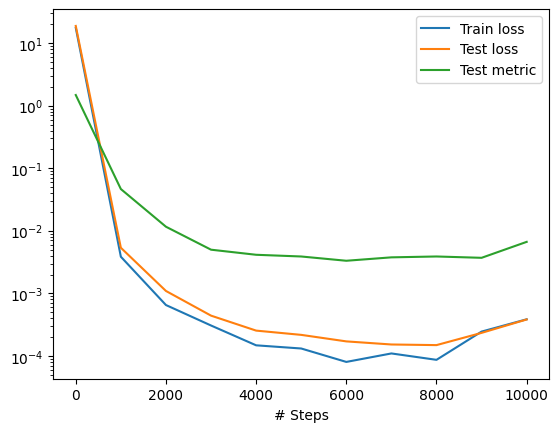

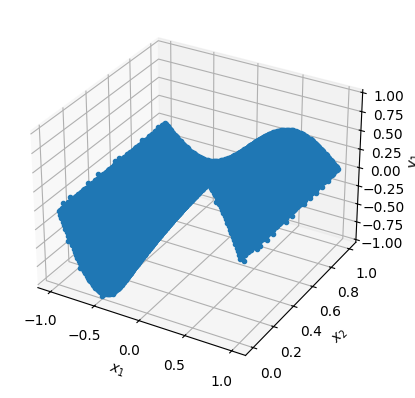

In [4]:
"""Backend supported: tensorflow.compat.v1, tensorflow, pytorch, jax, paddle"""
import deepxde as dde
import numpy as np
# Backend tensorflow.compat.v1 or tensorflow
from deepxde.backend import tf
# Backend pytorch
# import torch
# Backend jax
# import jax.numpy as jnp
# Backend paddle
# import paddle


def pde(x, y):
    # Most backends
    dy_t = dde.grad.jacobian(y, x, j=1)
    dy_xx = dde.grad.hessian(y, x, j=0)
    # Backend jax
    # dy_t, _ = dde.grad.jacobian(y, x, j=1)
    # dy_xx, _ = dde.grad.hessian(y, x, j=0)
    # Backend tensorflow.compat.v1 or tensorflow
    return (
        dy_t
        - dy_xx
        + tf.exp(-x[:, 1:])
        * (tf.sin(np.pi * x[:, 0:1]) - np.pi ** 2 * tf.sin(np.pi * x[:, 0:1]))
    )


def func(x):
    return np.sin(np.pi * x[:, 0:1]) * np.exp(-x[:, 1:])


geom = dde.geometry.Interval(-1, 1)
timedomain = dde.geometry.TimeDomain(0, 1)
geomtime = dde.geometry.GeometryXTime(geom, timedomain)

bc = dde.icbc.DirichletBC(geomtime, func, lambda _, on_boundary: on_boundary)
ic = dde.icbc.IC(geomtime, func, lambda _, on_initial: on_initial)
data = dde.data.TimePDE(
    geomtime,
    pde,
    [bc, ic],
    num_domain=40,
    num_boundary=20,
    num_initial=10,
    solution=func,
    num_test=10000,
)

layer_size = [2] + [32] * 3 + [1]
activation = "tanh"
initializer = "Glorot uniform"
net = dde.nn.FNN(layer_size, activation, initializer)

model = dde.Model(data, net)

model.compile("adam", lr=0.001, metrics=["l2 relative error"])
losshistory, train_state = model.train(iterations=10000)

dde.saveplot(losshistory, train_state, issave=True, isplot=True)

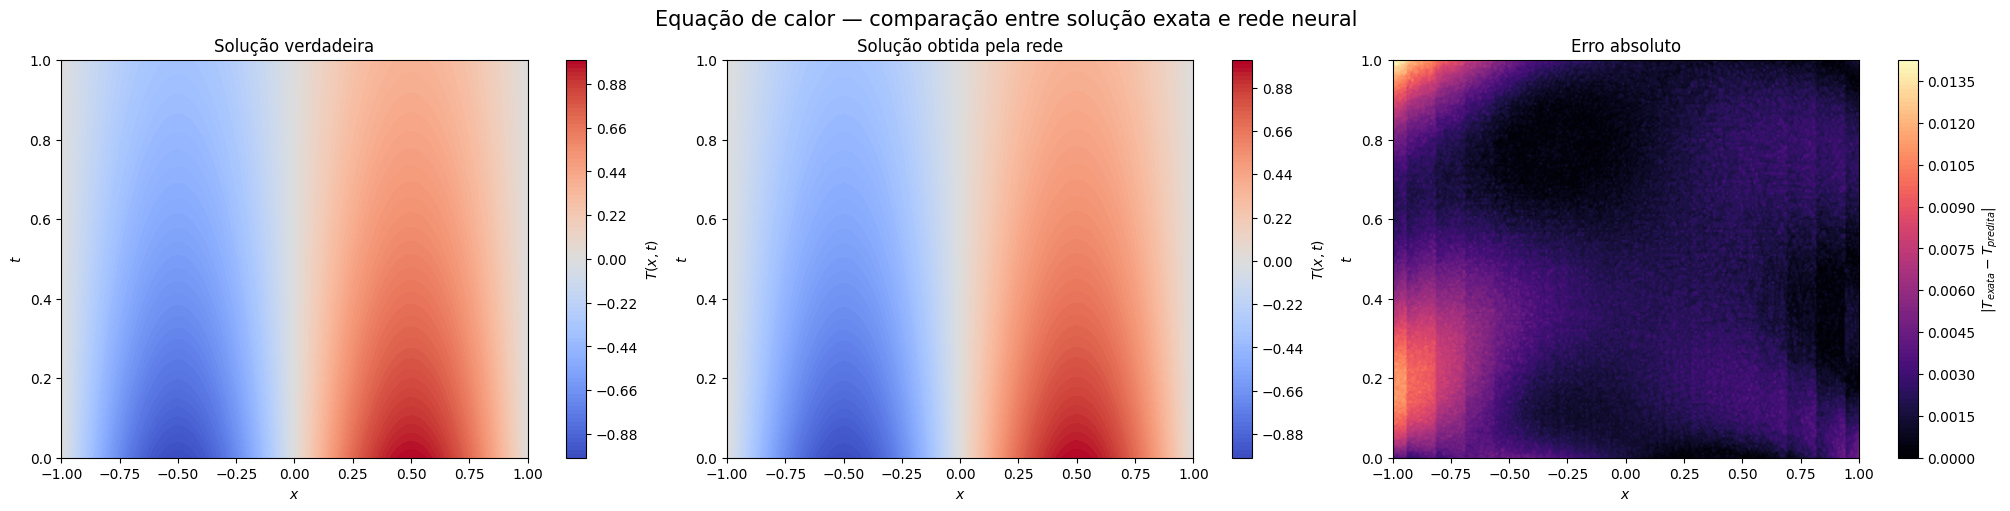

Erro absoluto máximo: 1.424637e-02
Erro absoluto médio: 2.399806e-03
Erro relativo L2: 0.006693853325709174


In [5]:
import matplotlib.pyplot as plt

x_plot = np.linspace(-1, 1, 256)
t_plot = np.linspace(0, 1, 201)

xx, tt = np.meshgrid(x_plot, t_plot)
X_plot = np.column_stack((xx.ravel(), tt.ravel()))

T_true = func(X_plot).reshape(len(t_plot), len(x_plot))
T_pred = model.predict(X_plot).reshape(len(t_plot), len(x_plot))

absolute_error = np.abs(T_true - T_pred)

vmin = min(T_true.min(), T_pred.min())
vmax = max(T_true.max(), T_pred.max())
error_max = max(absolute_error.max(), 1e-16)

fig, axes = plt.subplots(1, 3, figsize=(20, 5), constrained_layout=True)

solution_true = axes[0].contourf(
    xx, tt, T_true,
    levels=100,
    cmap="coolwarm",
    vmin=vmin,
    vmax=vmax
)

solution_pred = axes[1].contourf(
    xx, tt, T_pred,
    levels=100,
    cmap="coolwarm",
    vmin=vmin,
    vmax=vmax
)

error_plot = axes[2].contourf(
    xx, tt, absolute_error,
    levels=100,
    cmap="magma",
    vmin=0,
    vmax=error_max
)

axes[0].set_title("Solução verdadeira")
axes[1].set_title("Solução obtida pela rede")
axes[2].set_title("Erro absoluto")

for ax in axes:
    ax.set_xlabel("$x$")
    ax.set_ylabel("$t$")
    ax.set_aspect("auto")

fig.colorbar(solution_true, ax=axes[0], label="$T(x,t)$")
fig.colorbar(solution_pred, ax=axes[1], label="$T(x,t)$")
fig.colorbar(
    error_plot,
    ax=axes[2],
    label="$|T_{exata}-T_{predita}|$"
)

fig.suptitle(
    "Equação de calor — comparação entre solução exata e rede neural",
    fontsize=15
)

plt.show()

print(f"Erro absoluto máximo: {absolute_error.max():.6e}")
print(f"Erro absoluto médio: {absolute_error.mean():.6e}")
print(
    "Erro relativo L2:",
    dde.metrics.l2_relative_error(
        T_true.ravel()[:, None],
        T_pred.ravel()[:, None]
    )
)

# **2. Problemas Inversos**

## **2.1 - Parâmetro k da Eq. de Calor**

Vamos resolver um problema inverso para a equação de condução de calor com um parâmetro desconhecido $k$, associado à difusividade térmica:

$$\frac{\partial T}{\partial t} = k \frac{\partial^2 T}{\partial x^2}, \quad x \in [0, 1], \quad t \in [0, 1]$$

com a condição inicial

$$T(x, 0) = \sin(\pi x)$$

e as condições de contorno de Dirichlet

$$T(0, t) = T(1, t) = 0.$$

A solução de referência é

$$T(x,t) = e^{-0.4\pi^2t}\sin(\pi x),$$

sendo o valor verdadeiro do parâmetro $k = 0.4$, que será identificado pela rede a partir de observações da temperatura.

### Começando com um k distante

Compiling model...
'compile' took 0.003007 s

Training model...

Step      Train loss                                  Test loss                                   Test metric   
0         [1.10e+00, 1.05e-01, 9.24e-01, 2.05e-01]    [1.23e+00, 1.05e-01, 9.24e-01, 2.05e-01]    [2.18e+00]    
Iteração      0 | k = 5.00000000
1000      [5.03e-03, 3.00e-02, 6.06e-02, 3.95e-03]    [4.55e-03, 3.00e-02, 6.06e-02, 3.95e-03]    [4.75e-01]    
Iteração   1000 | k = 4.94769335
2000      [5.48e-03, 1.03e-02, 4.23e-02, 4.25e-03]    [5.88e-03, 1.03e-02, 4.23e-02, 4.25e-03]    [6.27e-01]    
Iteração   2000 | k = 4.77445078
3000      [4.59e-03, 2.42e-03, 2.49e-02, 3.36e-03]    [1.27e-02, 2.42e-03, 2.49e-02, 3.36e-03]    [8.67e-01]    
Iteração   3000 | k = 4.62227154
4000      [1.75e-03, 2.11e-03, 1.41e-02, 3.06e-03]    [2.24e-02, 2.11e-03, 1.41e-02, 3.06e-03]    [9.65e-01]    
Iteração   4000 | k = 4.52530146
5000      [5.25e-04, 2.44e-03, 8.33e-03, 2.94e-03]    [2.92e-02, 2.44e-03, 8.33e-03, 2.94e-0

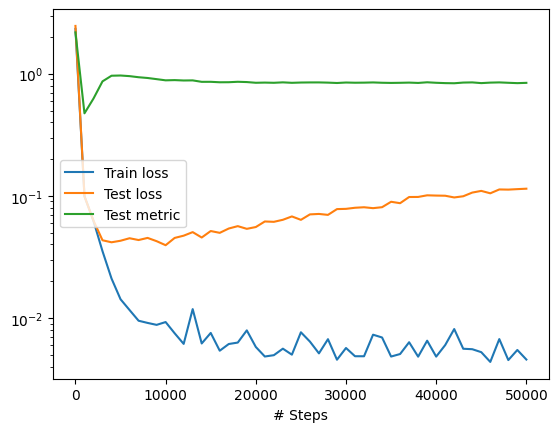

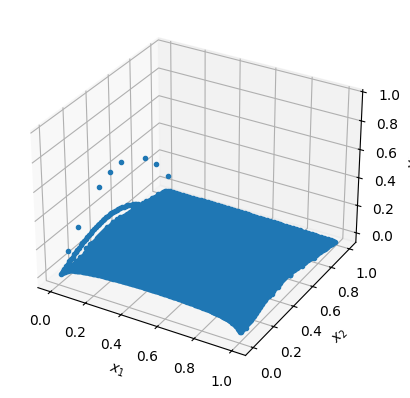

In [13]:
import deepxde as dde
import numpy as np


k_reference = 0.4
k = dde.Variable(5.0)

L = 1.0
n = 1
t_max = 1.0


def heat_eq_exact_solution(x, t):
    return np.exp(
        -(n**2 * np.pi**2 * k_reference * t) / L**2
    ) * np.sin(n * np.pi * x / L)


def func(x):
    return heat_eq_exact_solution(
        x[:, 0:1],
        x[:, 1:]
    )


def pde(x, y):
    dy_t = dde.grad.jacobian(y, x, i=0, j=1)
    dy_xx = dde.grad.hessian(y, x, i=0, j=0)

    return dy_t - k * dy_xx


geom = dde.geometry.Interval(0, L)
timedomain = dde.geometry.TimeDomain(0, t_max)
geomtime = dde.geometry.GeometryXTime(geom, timedomain)


bc = dde.icbc.DirichletBC(
    geomtime,
    lambda x: 0,
    lambda _, on_boundary: on_boundary
)

ic = dde.icbc.IC(
    geomtime,
    lambda x: np.sin(n * np.pi * x[:, 0:1] / L),
    lambda _, on_initial: on_initial
)


t_observe = 0.5

observe_x = np.vstack(
    (
        np.linspace(0, L, num=10),
        np.full((10,), t_observe)
    )
).T

observe_y = func(observe_x)

observe_bc = dde.icbc.PointSetBC(
    observe_x,
    observe_y,
    component=0
)


data = dde.data.TimePDE(
    geomtime,
    pde,
    [bc, ic, observe_bc],
    num_domain=40,
    num_boundary=20,
    num_initial=10,
    anchors=observe_x,
    solution=func,
    num_test=10000
)


layer_size = [2] + [32] * 3 + [1]
activation = "tanh"
initializer = "Glorot uniform"

net = dde.nn.FNN(
    layer_size,
    activation,
    initializer
)

model = dde.Model(data, net)


class VariableHistoryCallback(dde.callbacks.Callback):
    def __init__(self, variable, period=1000):
        super().__init__()

        self.variable = variable
        self.period = period
        self.counter = 0
        self.iterations = []
        self.values = []

    def _get_value(self):
        session = getattr(self.model, "sess", None)

        if session is not None:
            value = session.run(self.variable)
        else:
            value = self.variable.numpy()

        return float(np.asarray(value).squeeze())

    def _record_value(self):
        iteration = int(self.model.train_state.iteration)
        value = self._get_value()

        if not self.iterations or iteration != self.iterations[-1]:
            self.iterations.append(iteration)
            self.values.append(value)

        print(
            f"Iteração {iteration:6d} | "
            f"k = {value:.8f}"
        )

    def on_train_begin(self):
        self.counter = 0
        self._record_value()

    def on_epoch_end(self):
        self.counter += 1

        if self.counter >= self.period:
            self.counter = 0
            self._record_value()

    def on_train_end(self):
        final_iteration = int(self.model.train_state.iteration)

        if self.iterations[-1] != final_iteration:
            self._record_value()


model.compile(
    "adam",
    lr=0.001,
    metrics=["l2 relative error"],
    external_trainable_variables=k
)

variable = VariableHistoryCallback(
    k,
    period=1000
)

losshistory, train_state = model.train(
    iterations=50000,
    callbacks=[variable]
)

dde.saveplot(
    losshistory,
    train_state,
    issave=True,
    isplot=True
)

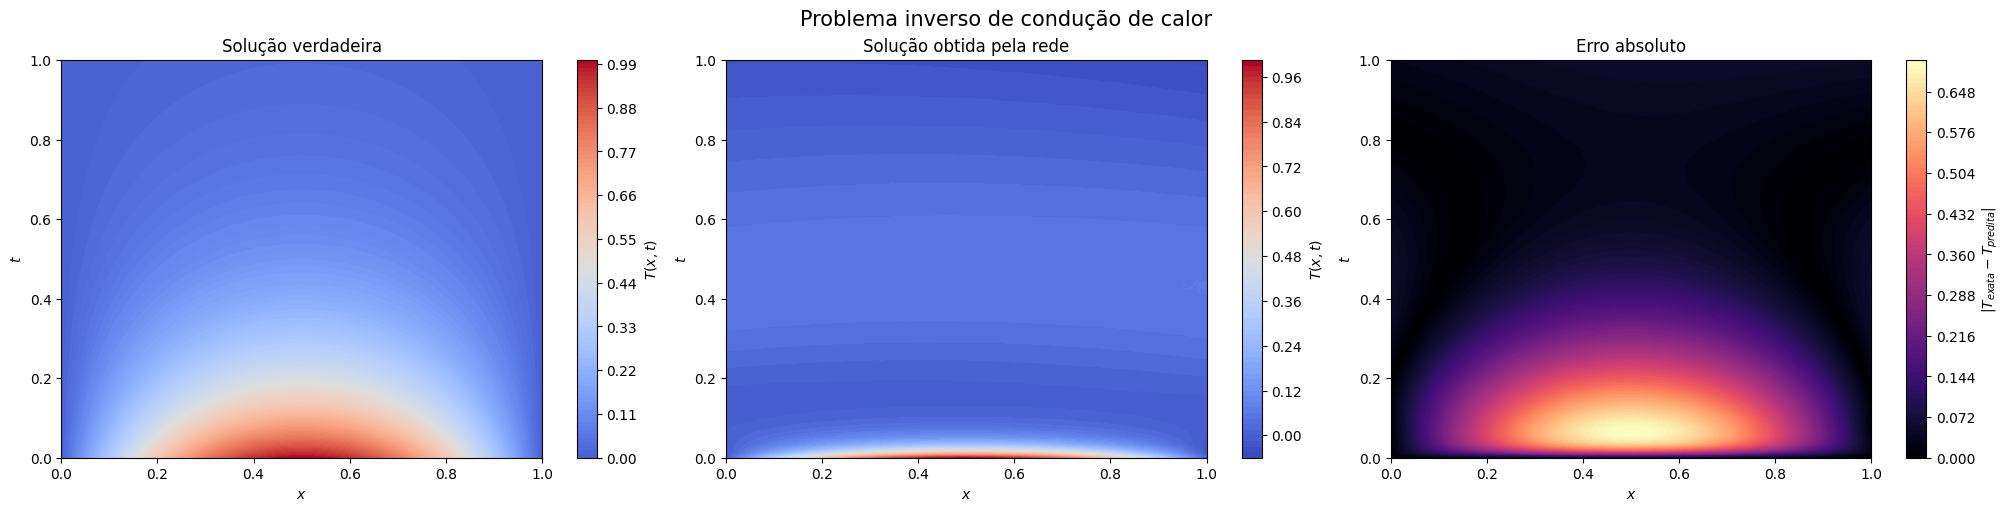

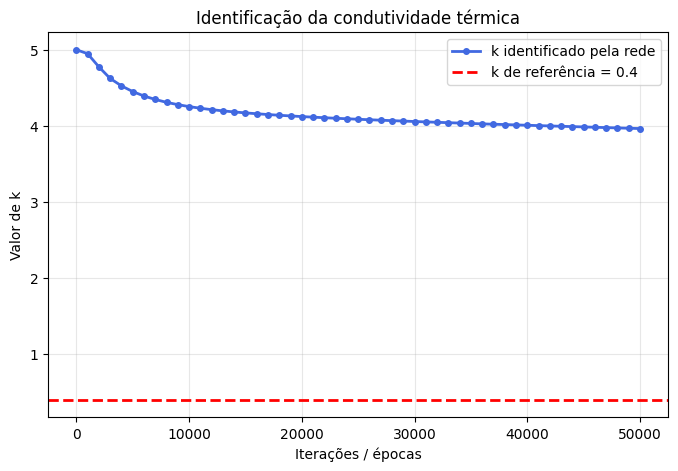

k de referência: 0.40000000
k identificado: 3.96382451
Erro absoluto máximo: 6.973071e-01
Erro absoluto médio: 1.272086e-01
Resíduo médio da PDE: 6.577326e-02
Erro relativo L2: 0.8225109690057446


In [14]:
import matplotlib.pyplot as plt


x_plot = np.linspace(0, L, 256)
t_plot = np.linspace(0, t_max, 201)

X_grid, T_grid = np.meshgrid(
    x_plot,
    t_plot
)

X_eval = np.column_stack(
    (
        X_grid.ravel(),
        T_grid.ravel()
    )
)

T_true = func(X_eval).reshape(T_grid.shape)
T_pred = model.predict(X_eval).reshape(T_grid.shape)

absolute_error = np.abs(T_true - T_pred)

vmin = min(
    T_true.min(),
    T_pred.min()
)

vmax = max(
    T_true.max(),
    T_pred.max()
)

error_max = max(
    absolute_error.max(),
    1e-16
)


fig, axes = plt.subplots(
    1,
    3,
    figsize=(20, 5),
    constrained_layout=True
)


plot_true = axes[0].contourf(
    X_grid,
    T_grid,
    T_true,
    levels=100,
    cmap="coolwarm",
    vmin=vmin,
    vmax=vmax
)

plot_pred = axes[1].contourf(
    X_grid,
    T_grid,
    T_pred,
    levels=100,
    cmap="coolwarm",
    vmin=vmin,
    vmax=vmax
)

plot_error = axes[2].contourf(
    X_grid,
    T_grid,
    absolute_error,
    levels=100,
    cmap="magma",
    vmin=0,
    vmax=error_max
)


axes[0].set_title("Solução verdadeira")
axes[1].set_title("Solução obtida pela rede")
axes[2].set_title("Erro absoluto")


for ax in axes:
    ax.set_xlabel("$x$")
    ax.set_ylabel("$t$")
    ax.set_aspect("auto")


fig.colorbar(
    plot_true,
    ax=axes[0],
    label="$T(x,t)$"
)

fig.colorbar(
    plot_pred,
    ax=axes[1],
    label="$T(x,t)$"
)

fig.colorbar(
    plot_error,
    ax=axes[2],
    label="$|T_{exata}-T_{predita}|$"
)

fig.suptitle(
    "Problema inverso de condução de calor",
    fontsize=15
)

plt.show()


k_iterations = np.asarray(
    variable.iterations,
    dtype=float
)

k_values = np.asarray(
    variable.values,
    dtype=float
)


fig_k, ax_k = plt.subplots(
    figsize=(8, 5)
)

ax_k.plot(
    k_iterations,
    k_values,
    color="royalblue",
    linewidth=2,
    marker="o",
    markersize=4,
    label="k identificado pela rede"
)

ax_k.axhline(
    k_reference,
    color="red",
    linestyle="--",
    linewidth=2,
    label="k de referência = 0.4"
)

ax_k.set_xlabel("Iterações / épocas")
ax_k.set_ylabel("Valor de k")
ax_k.set_title("Identificação da condutividade térmica")
ax_k.grid(True, alpha=0.3)
ax_k.legend()

plt.show()


residual = model.predict(
    X_eval,
    operator=pde
)

k_identified = k_values[-1]

print(f"k de referência: {k_reference:.8f}")
print(f"k identificado: {k_identified:.8f}")
print(f"Erro absoluto máximo: {absolute_error.max():.6e}")
print(f"Erro absoluto médio: {absolute_error.mean():.6e}")
print(f"Resíduo médio da PDE: {np.mean(np.abs(residual)):.6e}")
print(
    "Erro relativo L2:",
    dde.metrics.l2_relative_error(
        T_true.ravel()[:, None],
        T_pred.ravel()[:, None]
    )
)


np.savetxt(
    "heat_inverse_test.dat",
    np.hstack(
        (
            X_eval,
            T_true.ravel()[:, None],
            T_pred.ravel()[:, None],
            absolute_error.ravel()[:, None]
        )
    ),
    header="x t T_true T_pred absolute_error"
)

### Começando com um k próximo

Compiling model...
'compile' took 0.002813 s

Training model...

Step      Train loss                                  Test loss                                   Test metric   
0         [1.67e-01, 1.67e-01, 9.24e-01, 2.05e-01]    [1.74e-01, 1.67e-01, 9.24e-01, 2.05e-01]    [2.18e+00]    
Iteração      0 | k = 1.00000000
1000      [2.16e-03, 3.43e-03, 1.89e-03, 8.23e-04]    [2.06e-03, 3.43e-03, 1.89e-03, 8.23e-04]    [1.79e-01]    
Iteração   1000 | k = 0.36340353
2000      [9.67e-04, 5.09e-04, 2.03e-04, 5.19e-05]    [7.00e-04, 5.09e-04, 2.03e-04, 5.19e-05]    [6.17e-02]    
Iteração   2000 | k = 0.39548913
3000      [3.98e-04, 1.18e-04, 6.63e-05, 2.58e-05]    [3.40e-04, 1.18e-04, 6.63e-05, 2.58e-05]    [2.75e-02]    
Iteração   3000 | k = 0.39542979
4000      [1.63e-04, 6.51e-05, 1.84e-05, 2.35e-05]    [1.56e-04, 6.51e-05, 1.84e-05, 2.35e-05]    [3.17e-02]    
Iteração   4000 | k = 0.39562944
5000      [8.63e-05, 4.76e-05, 1.18e-05, 1.32e-05]    [1.03e-04, 4.76e-05, 1.18e-05, 1.32e-0

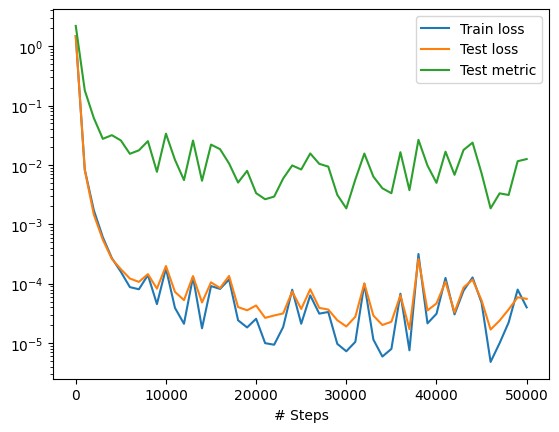

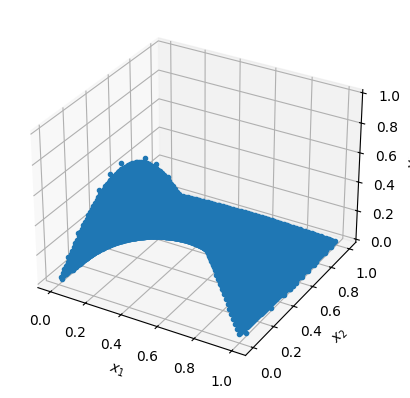

In [15]:
import deepxde as dde
import numpy as np


k_reference = 0.4
k = dde.Variable(1.0)

L = 1.0
n = 1
t_max = 1.0


def heat_eq_exact_solution(x, t):
    return np.exp(
        -(n**2 * np.pi**2 * k_reference * t) / L**2
    ) * np.sin(n * np.pi * x / L)


def func(x):
    return heat_eq_exact_solution(
        x[:, 0:1],
        x[:, 1:]
    )


def pde(x, y):
    dy_t = dde.grad.jacobian(y, x, i=0, j=1)
    dy_xx = dde.grad.hessian(y, x, i=0, j=0)

    return dy_t - k * dy_xx


geom = dde.geometry.Interval(0, L)
timedomain = dde.geometry.TimeDomain(0, t_max)
geomtime = dde.geometry.GeometryXTime(geom, timedomain)


bc = dde.icbc.DirichletBC(
    geomtime,
    lambda x: 0,
    lambda _, on_boundary: on_boundary
)

ic = dde.icbc.IC(
    geomtime,
    lambda x: np.sin(n * np.pi * x[:, 0:1] / L),
    lambda _, on_initial: on_initial
)


t_observe = 0.5

observe_x = np.vstack(
    (
        np.linspace(0, L, num=10),
        np.full((10,), t_observe)
    )
).T

observe_y = func(observe_x)

observe_bc = dde.icbc.PointSetBC(
    observe_x,
    observe_y,
    component=0
)


data = dde.data.TimePDE(
    geomtime,
    pde,
    [bc, ic, observe_bc],
    num_domain=40,
    num_boundary=20,
    num_initial=10,
    anchors=observe_x,
    solution=func,
    num_test=10000
)


layer_size = [2] + [32] * 3 + [1]
activation = "tanh"
initializer = "Glorot uniform"

net = dde.nn.FNN(
    layer_size,
    activation,
    initializer
)

model = dde.Model(data, net)


class VariableHistoryCallback(dde.callbacks.Callback):
    def __init__(self, variable, period=1000):
        super().__init__()

        self.variable = variable
        self.period = period
        self.counter = 0
        self.iterations = []
        self.values = []

    def _get_value(self):
        session = getattr(self.model, "sess", None)

        if session is not None:
            value = session.run(self.variable)
        else:
            value = self.variable.numpy()

        return float(np.asarray(value).squeeze())

    def _record_value(self):
        iteration = int(self.model.train_state.iteration)
        value = self._get_value()

        if not self.iterations or iteration != self.iterations[-1]:
            self.iterations.append(iteration)
            self.values.append(value)

        print(
            f"Iteração {iteration:6d} | "
            f"k = {value:.8f}"
        )

    def on_train_begin(self):
        self.counter = 0
        self._record_value()

    def on_epoch_end(self):
        self.counter += 1

        if self.counter >= self.period:
            self.counter = 0
            self._record_value()

    def on_train_end(self):
        final_iteration = int(self.model.train_state.iteration)

        if self.iterations[-1] != final_iteration:
            self._record_value()


model.compile(
    "adam",
    lr=0.001,
    metrics=["l2 relative error"],
    external_trainable_variables=k
)

variable = VariableHistoryCallback(
    k,
    period=1000
)

losshistory, train_state = model.train(
    iterations=50000,
    callbacks=[variable]
)

dde.saveplot(
    losshistory,
    train_state,
    issave=True,
    isplot=True
)

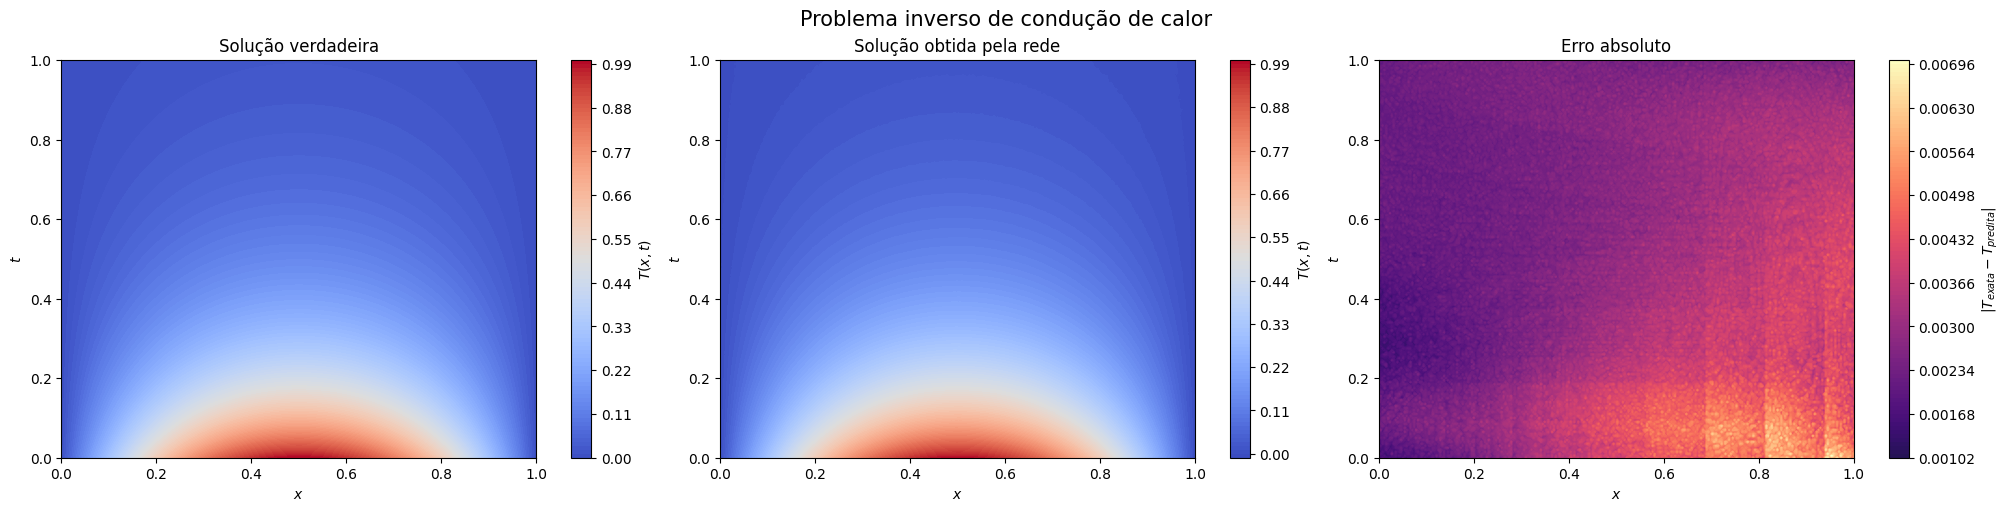

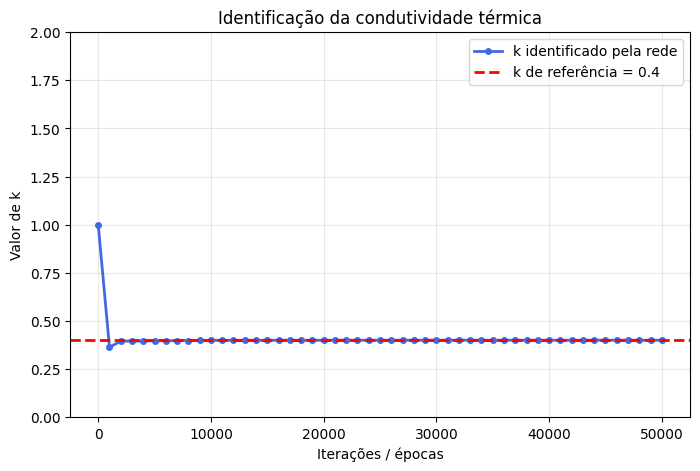

k de referência: 0.40000000
k identificado: 0.39999923
Erro absoluto máximo: 7.014764e-03
Erro absoluto médio: 3.011723e-03
Resíduo médio da PDE: 2.855452e-03
Erro relativo L2: 0.012370129802644132


In [17]:
import matplotlib.pyplot as plt


x_plot = np.linspace(0, L, 256)
t_plot = np.linspace(0, t_max, 201)

X_grid, T_grid = np.meshgrid(
    x_plot,
    t_plot
)

X_eval = np.column_stack(
    (
        X_grid.ravel(),
        T_grid.ravel()
    )
)

T_true = func(X_eval).reshape(T_grid.shape)
T_pred = model.predict(X_eval).reshape(T_grid.shape)

absolute_error = np.abs(T_true - T_pred)

vmin = min(
    T_true.min(),
    T_pred.min()
)

vmax = max(
    T_true.max(),
    T_pred.max()
)

error_max = max(
    absolute_error.max(),
    1e-16
)


fig, axes = plt.subplots(
    1,
    3,
    figsize=(20, 5),
    constrained_layout=True
)


plot_true = axes[0].contourf(
    X_grid,
    T_grid,
    T_true,
    levels=100,
    cmap="coolwarm",
    vmin=vmin,
    vmax=vmax
)

plot_pred = axes[1].contourf(
    X_grid,
    T_grid,
    T_pred,
    levels=100,
    cmap="coolwarm",
    vmin=vmin,
    vmax=vmax
)

plot_error = axes[2].contourf(
    X_grid,
    T_grid,
    absolute_error,
    levels=100,
    cmap="magma",
    vmin=0,
    vmax=error_max
)


axes[0].set_title("Solução verdadeira")
axes[1].set_title("Solução obtida pela rede")
axes[2].set_title("Erro absoluto")


for ax in axes:
    ax.set_xlabel("$x$")
    ax.set_ylabel("$t$")
    ax.set_aspect("auto")


fig.colorbar(
    plot_true,
    ax=axes[0],
    label="$T(x,t)$"
)

fig.colorbar(
    plot_pred,
    ax=axes[1],
    label="$T(x,t)$"
)

fig.colorbar(
    plot_error,
    ax=axes[2],
    label="$|T_{exata}-T_{predita}|$"
)

fig.suptitle(
    "Problema inverso de condução de calor",
    fontsize=15
)

plt.show()


k_iterations = np.asarray(
    variable.iterations,
    dtype=float
)

k_values = np.asarray(
    variable.values,
    dtype=float
)


fig_k, ax_k = plt.subplots(
    figsize=(8, 5)
)

ax_k.plot(
    k_iterations,
    k_values,
    color="royalblue",
    linewidth=2,
    marker="o",
    markersize=4,
    label="k identificado pela rede"
)

ax_k.axhline(
    k_reference,
    color="red",
    linestyle="--",
    linewidth=2,
    label="k de referência = 0.4"
)

ax_k.set_xlabel("Iterações / épocas")
ax_k.set_ylabel("Valor de k")
ax_k.set_ylim([0, 2])
ax_k.set_title("Identificação da condutividade térmica")
ax_k.grid(True, alpha=0.3)
ax_k.legend()

plt.show()


residual = model.predict(
    X_eval,
    operator=pde
)

k_identified = k_values[-1]

print(f"k de referência: {k_reference:.8f}")
print(f"k identificado: {k_identified:.8f}")
print(f"Erro absoluto máximo: {absolute_error.max():.6e}")
print(f"Erro absoluto médio: {absolute_error.mean():.6e}")
print(f"Resíduo médio da PDE: {np.mean(np.abs(residual)):.6e}")
print(
    "Erro relativo L2:",
    dde.metrics.l2_relative_error(
        T_true.ravel()[:, None],
        T_pred.ravel()[:, None]
    )
)


np.savetxt(
    "heat_inverse_test.dat",
    np.hstack(
        (
            X_eval,
            T_true.ravel()[:, None],
            T_pred.ravel()[:, None],
            absolute_error.ravel()[:, None]
        )
    ),
    header="x t T_true T_pred absolute_error"
)

## **2.2 - Parâmetro C da Difusão**

### Configuração do problema

Vamos resolver um problema inverso para a equação de difusão com um parâmetro desconhecido $C$:

$$ \frac{\partial y}{\partial t} = C \frac{\partial^2 y}{\partial x^2} - e^{-t}(\sin(\pi x) - \pi^2 \sin(\pi x)), \quad x \in [-1, 1], \quad t \in [0, 1] $$

com a condição inicial

$$ y(x, 0) = \sin(\pi x) $$

e a condição de contorno de Dirichlet

$$ y(-1, t) = y(1, t) = 0. $$

A solução de referência é $y = e^{-t} \sin(\pi x)$.

Compiling model...
'compile' took 0.003034 s

Training model...

Step      Train loss                                  Test loss                                   Test metric   
0         [1.60e+01, 1.97e-01, 8.52e-01, 2.68e-01]    [1.89e+01, 1.97e-01, 8.52e-01, 2.68e-01]    [1.48e+00]    
Iteração 0: C = 2.00000000
1000      [5.47e-03, 2.68e-02, 5.25e-02, 1.80e-02]    [7.32e-03, 2.68e-02, 5.25e-02, 1.80e-02]    [3.93e-01]    
Iteração 1000: C = 1.99456680
2000      [3.27e-03, 5.59e-03, 1.36e-02, 7.28e-03]    [4.96e-03, 5.59e-03, 1.36e-02, 7.28e-03]    [3.69e-01]    
Iteração 2000: C = 1.63801253
3000      [7.85e-04, 1.15e-03, 1.91e-03, 2.62e-03]    [2.28e-03, 1.15e-03, 1.91e-03, 2.62e-03]    [2.25e-01]    
Iteração 3000: C = 1.31264520
4000      [9.38e-04, 2.87e-04, 7.57e-05, 3.27e-04]    [1.75e-03, 2.87e-04, 7.57e-05, 3.27e-04]    [7.85e-02]    
Iteração 4000: C = 1.09816313
5000      [3.90e-04, 1.19e-04, 6.64e-06, 5.30e-05]    [9.55e-04, 1.19e-04, 6.64e-06, 5.30e-05]    [2.99e-02]  

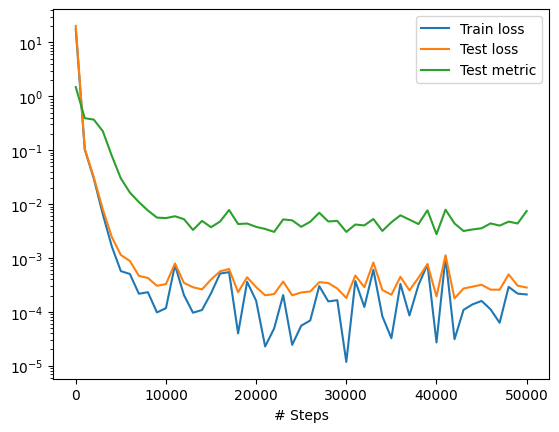

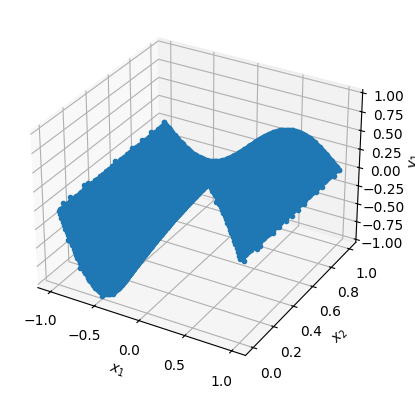

In [10]:
"""Backend supported: tensorflow.compat.v1, tensorflow, pytorch, paddle"""
import deepxde as dde
import numpy as np
# Backend tensorflow.compat.v1 or tensorflow
from deepxde.backend import tf
import matplotlib.pyplot as plt

C = dde.Variable(2.0)


def pde(x, y):
    dy_t = dde.grad.jacobian(y, x, i=0, j=1)
    dy_xx = dde.grad.hessian(y, x, i=0, j=0)
    # Backend tensorflow.compat.v1 or tensorflow
    return (
        dy_t
        - C * dy_xx
        + tf.exp(-x[:, 1:])
        * (tf.sin(np.pi * x[:, 0:1]) - np.pi ** 2 * tf.sin(np.pi * x[:, 0:1]))
    )


def func(x):
    return np.sin(np.pi * x[:, 0:1]) * np.exp(-x[:, 1:])


geom = dde.geometry.Interval(-1, 1)
timedomain = dde.geometry.TimeDomain(0, 1)
geomtime = dde.geometry.GeometryXTime(geom, timedomain)

bc = dde.icbc.DirichletBC(geomtime, func, lambda _, on_boundary: on_boundary)
ic = dde.icbc.IC(geomtime, func, lambda _, on_initial: on_initial)

observe_x = np.vstack((np.linspace(-1, 1, num=10), np.full((10), 1))).T
observe_y = dde.icbc.PointSetBC(observe_x, func(observe_x), component=0)

data = dde.data.TimePDE(
    geomtime,
    pde,
    [bc, ic, observe_y],
    num_domain=40,
    num_boundary=20,
    num_initial=10,
    anchors=observe_x,
    solution=func,
    num_test=10000,
)

layer_size = [2] + [32] * 3 + [1]
activation = "tanh"
initializer = "Glorot uniform"
net = dde.nn.FNN(layer_size, activation, initializer)

model = dde.Model(data, net)

model.compile(
    "adam", lr=0.001, metrics=["l2 relative error"], external_trainable_variables=C
)

class VariableHistoryCallback(dde.callbacks.Callback):
    def __init__(self, variable, period=1000):
        super().__init__()
        self.variable = variable
        self.period = period
        self.counter = 0
        self.iterations = []
        self.values = []

    def _get_value(self):
        if hasattr(self.model, "sess"):
            value = self.model.sess.run(self.variable)
        else:
            value = self.variable.numpy()

        return float(np.asarray(value).squeeze())

    def _record_value(self):
        iteration = int(self.model.train_state.iteration)
        value = self._get_value()

        if not self.iterations or iteration != self.iterations[-1]:
            self.iterations.append(iteration)
            self.values.append(value)

        print(f"Iteração {iteration}: C = {value:.8f}")

    def on_train_begin(self):
        self.counter = 0
        self._record_value()

    def on_epoch_end(self):
        self.counter += 1

        if self.counter >= self.period:
            self.counter = 0
            self._record_value()

    def on_train_end(self):
        final_iteration = int(self.model.train_state.iteration)

        if self.iterations[-1] != final_iteration:
            self._record_value()


variable = VariableHistoryCallback(C, period=1000)

losshistory, train_state = model.train(
    iterations=50000,
    callbacks=[variable]
)

dde.saveplot(losshistory, train_state, issave=True, isplot=True)

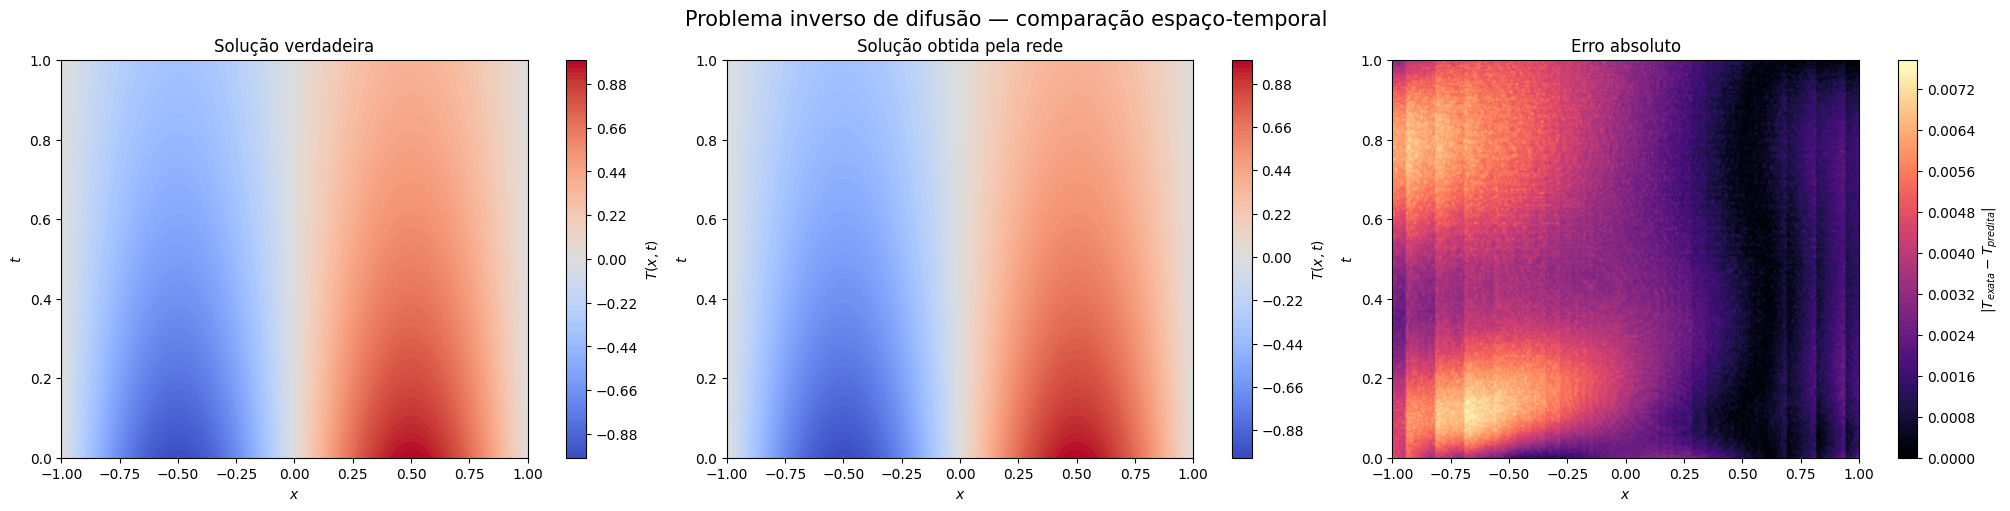

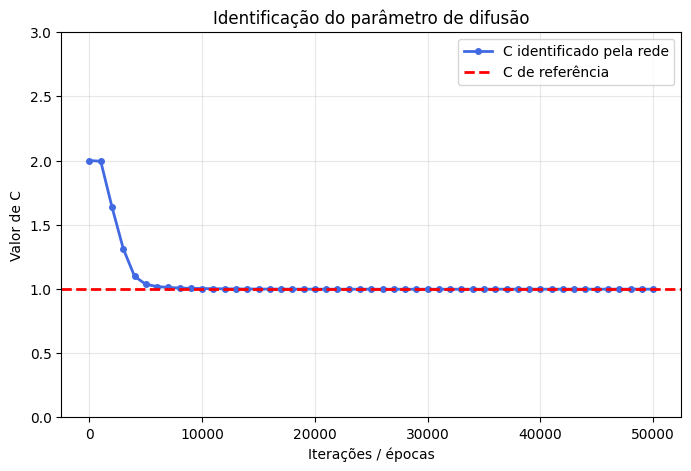

C de referência: 1.00000000
C identificado: 0.99775755
Erro absoluto máximo: 7.708433e-03
Erro absoluto médio: 2.884347e-03
Erro relativo L2: 0.007366055984131107


In [12]:
C_reference = 1.0

x_plot = np.linspace(-1, 1, 256)
t_plot = np.linspace(0, 1, 201)

X_grid, T_grid = np.meshgrid(x_plot, t_plot)

X_eval = np.column_stack(
    (X_grid.ravel(), T_grid.ravel())
)

T_true = func(X_eval).reshape(T_grid.shape)
T_pred = model.predict(X_eval).reshape(T_grid.shape)

absolute_error = np.abs(T_true - T_pred)

vmin = min(T_true.min(), T_pred.min())
vmax = max(T_true.max(), T_pred.max())
error_max = max(absolute_error.max(), 1e-16)

fig, axes = plt.subplots(
    1,
    3,
    figsize=(20, 5),
    constrained_layout=True
)

plot_true = axes[0].contourf(
    X_grid,
    T_grid,
    T_true,
    levels=100,
    cmap="coolwarm",
    vmin=vmin,
    vmax=vmax
)

plot_pred = axes[1].contourf(
    X_grid,
    T_grid,
    T_pred,
    levels=100,
    cmap="coolwarm",
    vmin=vmin,
    vmax=vmax
)

plot_error = axes[2].contourf(
    X_grid,
    T_grid,
    absolute_error,
    levels=100,
    cmap="magma",
    vmin=0,
    vmax=error_max
)

axes[0].set_title("Solução verdadeira")
axes[1].set_title("Solução obtida pela rede")
axes[2].set_title("Erro absoluto")

for ax in axes:
    ax.set_xlabel("$x$")
    ax.set_ylabel("$t$")
    ax.set_aspect("auto")

fig.colorbar(plot_true, ax=axes[0], label="$T(x,t)$")
fig.colorbar(plot_pred, ax=axes[1], label="$T(x,t)$")
fig.colorbar(
    plot_error,
    ax=axes[2],
    label="$|T_{exata}-T_{predita}|$"
)

fig.suptitle(
    "Problema inverso de difusão — comparação espaço-temporal",
    fontsize=15
)

plt.show()

fig_c, ax_c = plt.subplots(figsize=(8, 5))

ax_c.plot(
    variable.iterations,
    variable.values,
    color="royalblue",
    linewidth=2,
    marker="o",
    markersize=4,
    label="C identificado pela rede"
)

ax_c.axhline(
    C_reference,
    color="red",
    linestyle="--",
    linewidth=2,
    label="C de referência"
)

ax_c.set_xlabel("Iterações / épocas")
ax_c.set_ylabel("Valor de C")
ax_c.set_ylim([0, 3])
ax_c.set_title("Identificação do parâmetro de difusão")
ax_c.grid(True, alpha=0.3)
ax_c.legend()

plt.show()

print(f"C de referência: {C_reference:.8f}")
print(f"C identificado: {variable.values[-1]:.8f}")
print(f"Erro absoluto máximo: {absolute_error.max():.6e}")
print(f"Erro absoluto médio: {absolute_error.mean():.6e}")
print(
    "Erro relativo L2:",
    dde.metrics.l2_relative_error(
        T_true.ravel()[:, None],
        T_pred.ravel()[:, None]
    )
)